# **Computer Vision Project: Facial Skin Ageing Classification**

# 0.Import Library

In [205]:
import os
import shutil
import random
import pathlib
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from shutil import copyfile
from pathlib import Path
from tqdm import tqdm as tq

# Libraries untuk data preprocessing
import cv2
import skimage
from PIL import Image
from skimage import io, img_as_ubyte
from skimage.transform import resize, rotate, AffineTransform, warp
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Libraries untuk modeling
import keras
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img 
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

# 1.Loading Dataset

In [2]:
# Download latest version
path = kagglehub.dataset_download("siddheshbhatt/facial-skin-ageing", output_dir=r"./dataset")

print("Path to dataset files:", path)

100%|██████████| 239M/239M [00:20<00:00, 12.1MB/s] 

Extracting files...


Path to dataset files: ./dataset


# 2.Data Preprocessing

In [3]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
lung_img = {}

path = 'dataset'
path_sub = os.path.join(path, 'skin_ageing_symptoms')
os.listdir(path_sub)

['acne', 'clear_face', 'darkspots', 'puffy_eyes', 'wrinkles']

In [4]:
for i in os.listdir(path_sub):
    lung_img[i] = os.listdir(os.path.join(path_sub, i))

lung_img

{'acne': ['1.png',
  '102.png',
  '108.png',
  '109.png',
  '110.png',
  '113.png',
  '115.png',
  '116.png',
  '12.png',
  '120.png',
  '123.png',
  '124.png',
  '131.png',
  '135.png',
  '136.png',
  '137.png',
  '138.png',
  '146.png',
  '147.png',
  '152.png',
  '154.png',
  '156.png',
  '158.png',
  '16.png',
  '165.png',
  '17.png',
  '170.png',
  '174.png',
  '176.png',
  '178.png',
  '179.png',
  '18.png',
  '183.png',
  '188.png',
  '189.png',
  '190.png',
  '193.png',
  '194.png',
  '2.png',
  '203.png',
  '204.png',
  '205.png',
  '208.png',
  '21.png',
  '211.png',
  '212.png',
  '215.png',
  '22.png',
  '225.png',
  '227.png',
  '3.png',
  '4.png',
  '43.png',
  '46.png',
  '49.png',
  '5.png',
  '50.png',
  '52.png',
  '54.png',
  '60.png',
  '63.png',
  '66.png',
  '73.png',
  '75.png',
  '80.png',
  '81.png',
  '83.png',
  '86.png',
  '87.png',
  '89.png',
  '9.png',
  '92.png',
  '93.png',
  '98.png',
  '99.png',
  'dark_0_levle0_58.png',
  'dark_10_levle3_94.png',
  '

In [5]:
class_name = lung_img.keys()
n_class = len(lung_img.keys())

print(f'Jumlah Kelas: {n_class}')
print(f'Nama Kelas: {class_name}')

Jumlah Kelas: 5
Nama Kelas: dict_keys(['acne', 'clear_face', 'darkspots', 'puffy_eyes', 'wrinkles'])


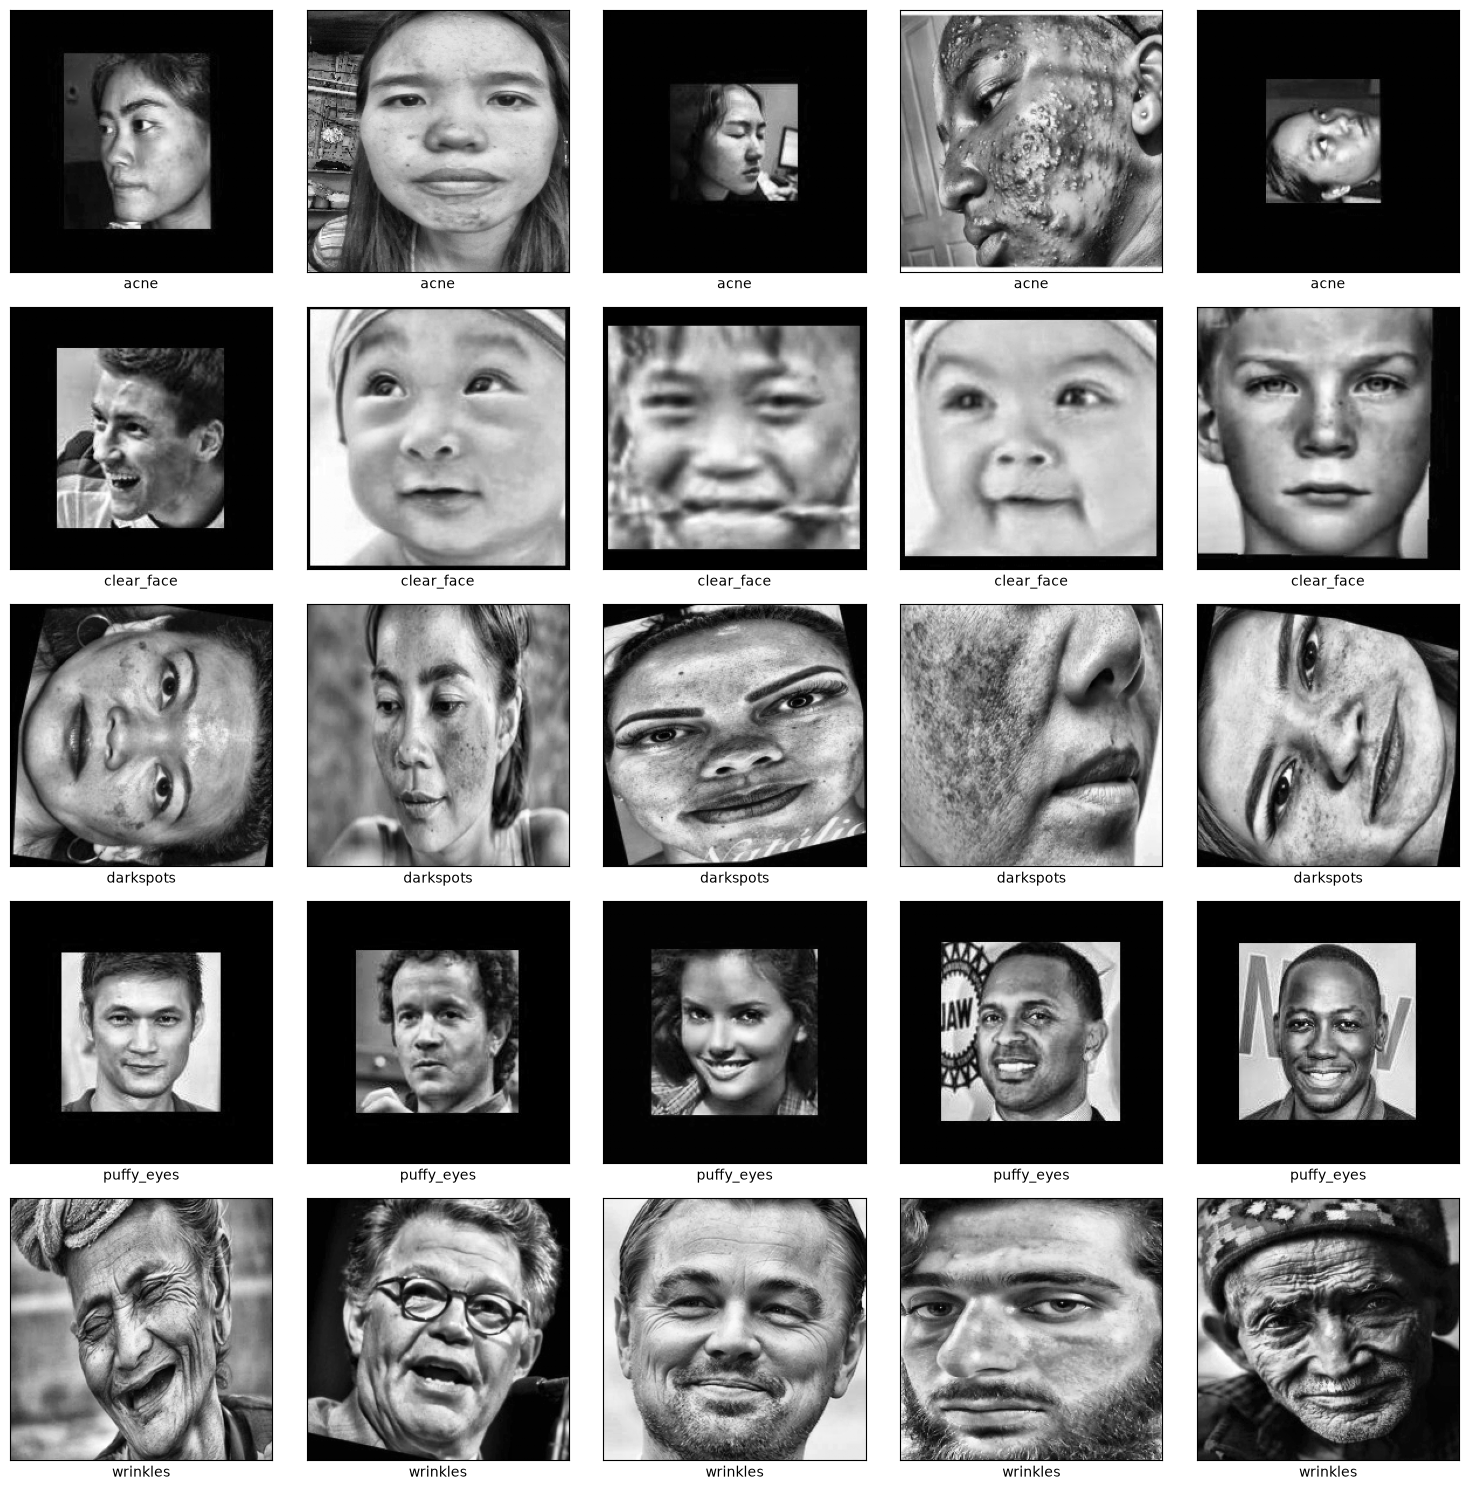

In [6]:
# Menampilkan 5 gambar secara masing-masing kelas yang ada dalam data
fig, ax = plt.subplots(n_class, 5, figsize=(15, 15))

for i, cls in enumerate(os.listdir(path_sub)):
    images = np.random.choice(lung_img[cls], 5, replace=False)

    for j, img in enumerate(images):
        img_path = os.path.join(path_sub, cls, img)
        im = Image.open(img_path).convert("L")
        ax[i, j].imshow(im, cmap='gray')
        ax[i, j].set(xlabel=cls, xticks=[], yticks=[])

fig.tight_layout()

In [7]:
lung_path = 'dataset/skin_ageing_symptoms'

file_name = []
labels = []
full_path = []

data = [
    (name, os.path.basename(path), os.path.join(path, name))
    for path, subdirs, files in os.walk(lung_path)
    for name in files
]

In [8]:
data

[('1.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\1.png'),
 ('102.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\102.png'),
 ('108.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\108.png'),
 ('109.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\109.png'),
 ('110.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\110.png'),
 ('113.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\113.png'),
 ('115.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\115.png'),
 ('116.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\116.png'),
 ('12.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\12.png'),
 ('120.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\120.png'),
 ('123.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\123.png'),
 ('124.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\124.png'),
 ('131.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\131.png'),
 ('135.png', 'acne', 'dataset/skin_ageing_symptoms\\acne\\135.png'),
 ('136.png', 'acne', 'dataset/skin_agein

In [9]:
file_name = [x[0] for x in data]
file_name

['1.png',
 '102.png',
 '108.png',
 '109.png',
 '110.png',
 '113.png',
 '115.png',
 '116.png',
 '12.png',
 '120.png',
 '123.png',
 '124.png',
 '131.png',
 '135.png',
 '136.png',
 '137.png',
 '138.png',
 '146.png',
 '147.png',
 '152.png',
 '154.png',
 '156.png',
 '158.png',
 '16.png',
 '165.png',
 '17.png',
 '170.png',
 '174.png',
 '176.png',
 '178.png',
 '179.png',
 '18.png',
 '183.png',
 '188.png',
 '189.png',
 '190.png',
 '193.png',
 '194.png',
 '2.png',
 '203.png',
 '204.png',
 '205.png',
 '208.png',
 '21.png',
 '211.png',
 '212.png',
 '215.png',
 '22.png',
 '225.png',
 '227.png',
 '3.png',
 '4.png',
 '43.png',
 '46.png',
 '49.png',
 '5.png',
 '50.png',
 '52.png',
 '54.png',
 '60.png',
 '63.png',
 '66.png',
 '73.png',
 '75.png',
 '80.png',
 '81.png',
 '83.png',
 '86.png',
 '87.png',
 '89.png',
 '9.png',
 '92.png',
 '93.png',
 '98.png',
 '99.png',
 'dark_0_levle0_58.png',
 'dark_10_levle3_94.png',
 'dark_11_acne3 (004).png',
 'dark_12_levle0_58.png',
 'dark_13_levle0_59.png',
 'dark_1

In [10]:
labels = [x[1] for x in data]
labels

['acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 'acne',
 

In [11]:
full_path = [x[2] for x in data]
full_path

['dataset/skin_ageing_symptoms\\acne\\1.png',
 'dataset/skin_ageing_symptoms\\acne\\102.png',
 'dataset/skin_ageing_symptoms\\acne\\108.png',
 'dataset/skin_ageing_symptoms\\acne\\109.png',
 'dataset/skin_ageing_symptoms\\acne\\110.png',
 'dataset/skin_ageing_symptoms\\acne\\113.png',
 'dataset/skin_ageing_symptoms\\acne\\115.png',
 'dataset/skin_ageing_symptoms\\acne\\116.png',
 'dataset/skin_ageing_symptoms\\acne\\12.png',
 'dataset/skin_ageing_symptoms\\acne\\120.png',
 'dataset/skin_ageing_symptoms\\acne\\123.png',
 'dataset/skin_ageing_symptoms\\acne\\124.png',
 'dataset/skin_ageing_symptoms\\acne\\131.png',
 'dataset/skin_ageing_symptoms\\acne\\135.png',
 'dataset/skin_ageing_symptoms\\acne\\136.png',
 'dataset/skin_ageing_symptoms\\acne\\137.png',
 'dataset/skin_ageing_symptoms\\acne\\138.png',
 'dataset/skin_ageing_symptoms\\acne\\146.png',
 'dataset/skin_ageing_symptoms\\acne\\147.png',
 'dataset/skin_ageing_symptoms\\acne\\152.png',
 'dataset/skin_ageing_symptoms\\acne\\154.p

In [12]:
df = pd.DataFrame({
    'file_name': file_name,
    'label': labels,
    'path': full_path
})

In [13]:
df.head(-10)

,file_name,label,path
0,1.png,acne,dataset/skin_ageing_symptoms\acne\1.png
1,102.png,acne,dataset/skin_ageing_symptoms\acne\102.png
2,108.png,acne,dataset/skin_ageing_symptoms\acne\108.png
3,109.png,acne,dataset/skin_ageing_symptoms\acne\109.png
4,110.png,acne,dataset/skin_ageing_symptoms\acne\110.png
...,...,...,...
3245,skinv2_wrinkles_light_01651.png,wrinkles,dataset/skin_ageing_symptoms\wrinkles\skinv2_w...
3246,skinv2_wrinkles_light_01657.png,wrinkles,dataset/skin_ageing_symptoms\wrinkles\skinv2_w...
3247,skinv2_wrinkles_light_01662.png,wrinkles,dataset/skin_ageing_symptoms\wrinkles\skinv2_w...
3248,skinv2_wrinkles_light_01665.png,wrinkles,dataset/skin_ageing_symptoms\wrinkles\skinv2_w...


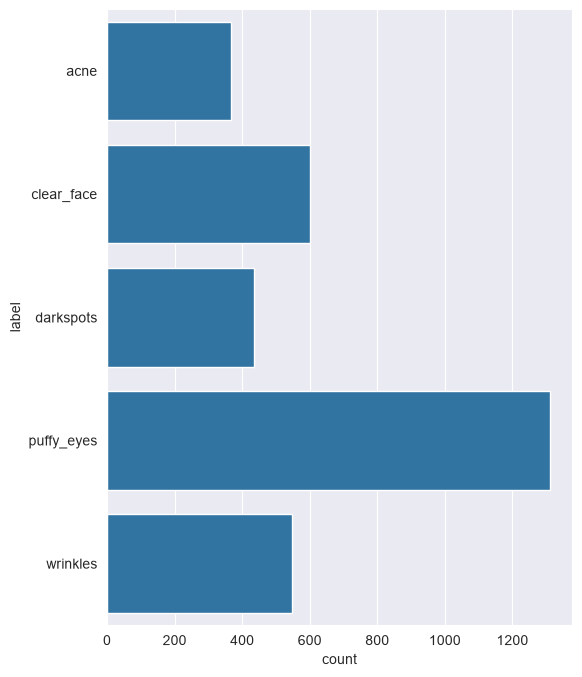

In [14]:
# Visualisasi distribusi kelas
Label = df['label']
plt.figure(figsize=(6, 8))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [15]:
count_label = df["label"].value_counts()
print(count_label)

label
puffy_eyes    1311
clear_face     600
wrinkles       548
darkspots      434
acne           367
Name: count, dtype: int64


In [16]:
class imageAugmentation:
    def __init__(self, img) -> None:
        self.img = img
        self.image = cv2.cvtColor(self.img, 0)
        self.image = cv2.resize(self.img, (244, 244))

    def anticlockwise_rotation(self):
        sudut = random.randint(0, 180)
        return rotate(self.image, sudut)

    def clockwise_rotation(self):
        sudut = random.randint(0,180)
        return rotate(self.image, -sudut)

    def flip_up_down(self):
        return np.flipud(self.image)

    def add_brightness(self):
        return adjust_gamma(self.image, gamma=0.5, gain=1)

    def blur_image(self):
        return cv2.GaussianBlur(self.image, (9, 9), 0)

    def sheared(self):
        transform = AffineTransform(shear=0.2)
        return warp(self.image, transform, mode='wrap')

    def warp_shift(self):
        transform = AffineTransform(translation=(0, 40))
        return warp(self.image, transform, mode='wrap')

In [17]:
transformations = {
    "rotate anticlockwise": lambda img: imageAugmentation(img).anticlockwise_rotation(),
    "rotate clockwise": lambda img: imageAugmentation(img).clockwise_rotation(),
    "warp_shift": lambda img: imageAugmentation(img).warp_shift(),
    "blurring image": lambda img: imageAugmentation(img).blur_image(),
    "add brightness": lambda img: imageAugmentation(img).add_brightness(),
    "flip up down": lambda img: imageAugmentation(img).flip_up_down(),
    "shear image": lambda img: imageAugmentation(img).sheared(),
}

In [18]:
def read_img(images_path):
    return [os.path.join(images_path, im) for im in os.listdir(images_path)]

In [19]:
def runAugmentation(transformations, images, images_path, generate_img):
    i = 1
    image_to_generate = generate_img
    while i <= image_to_generate:
        image = random.choice(images)
        try:
            original_img = io.imread(image)
            transformed_img = None
            n = 0  # Variabel untuk melakukan iterasi sampai jumlah transformasi yang akan diterapkan
            transformations_count = random.randint(1, len(transformations))

            while n <= transformations_count:
                key = random.choice(list(transformations))
                transformed_img = transformations[key](original_img)
                n = n + 1

            new_image_path = '%s/augmented_image_%s.jpg' % (images_path, i)
            # Mengonversi gambar ke format byte yang tidak ditandatangani, dengan nilai dalam [0, 255]
            transformed_img = img_as_ubyte(transformed_img)
            # Simpan hasil transformasi augmentasi pada gambar
            cv2.imwrite(new_image_path, transformed_img)
            i += 1
        except ValueError as e:
            print('could not read the',image ,':',e,'hence skipping it.')

In [20]:
# Augmentasi data acne
acne_path = os.path.join(lung_path, 'acne')
acne_img = read_img(acne_path)
acne_img

['dataset/skin_ageing_symptoms\\acne\\1.png',
 'dataset/skin_ageing_symptoms\\acne\\102.png',
 'dataset/skin_ageing_symptoms\\acne\\108.png',
 'dataset/skin_ageing_symptoms\\acne\\109.png',
 'dataset/skin_ageing_symptoms\\acne\\110.png',
 'dataset/skin_ageing_symptoms\\acne\\113.png',
 'dataset/skin_ageing_symptoms\\acne\\115.png',
 'dataset/skin_ageing_symptoms\\acne\\116.png',
 'dataset/skin_ageing_symptoms\\acne\\12.png',
 'dataset/skin_ageing_symptoms\\acne\\120.png',
 'dataset/skin_ageing_symptoms\\acne\\123.png',
 'dataset/skin_ageing_symptoms\\acne\\124.png',
 'dataset/skin_ageing_symptoms\\acne\\131.png',
 'dataset/skin_ageing_symptoms\\acne\\135.png',
 'dataset/skin_ageing_symptoms\\acne\\136.png',
 'dataset/skin_ageing_symptoms\\acne\\137.png',
 'dataset/skin_ageing_symptoms\\acne\\138.png',
 'dataset/skin_ageing_symptoms\\acne\\146.png',
 'dataset/skin_ageing_symptoms\\acne\\147.png',
 'dataset/skin_ageing_symptoms\\acne\\152.png',
 'dataset/skin_ageing_symptoms\\acne\\154.p

In [21]:
print(f"Jumlah gambar original: {len(acne_img)}")

Jumlah gambar original: 367


In [22]:
runAugmentation(transformations, acne_img, acne_path, 2500)

In [23]:
# Augmentasi data clear face
clear_face_path = os.path.join(lung_path, 'clear_face')
clear_face_img = read_img(clear_face_path)
clear_face_img

['dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170110215927291.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170110220235233.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170110220541850.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170110221714752.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170110221811823.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170110225417177.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170116201328751.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170117135444407.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_0_20170120220628194.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_1_20170110220523360.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_1_20170110223455893.jpg.chip.png',
 'dataset/skin_ageing_symptoms\\clear_face\\10_0_1_20170110223848885.jpg.chi

In [24]:
print(f"Jumlah gambar original: {len(clear_face_img)}")

Jumlah gambar original: 600


In [25]:
runAugmentation(transformations, clear_face_img, clear_face_path, 2500)

In [26]:
# Augmentasi data darkspots
darkspots_path = os.path.join(lung_path, 'darkspots')
darkspots_img = read_img(darkspots_path)
darkspots_img

['dataset/skin_ageing_symptoms\\darkspots\\0033_aug_1.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0033_aug_2.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0079_aug_1.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0079_aug_2.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0079_aug_3.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0085_aug_1.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0085_aug_2.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0090_aug_2.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0090_aug_3.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0090_aug_4.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0102.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0104_aug_1.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0104_aug_4.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0107_aug_1.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0107_aug_4.png',
 'dataset/skin_ageing_symptoms\\darkspots\\0123_aug_2.png',
 'dataset/skin_ageing_symptoms\\darkspots\\012

In [27]:
print(f"Jumlah gambar original: {len(darkspots_img)}")

Jumlah gambar original: 434


In [28]:
runAugmentation(transformations, darkspots_img, darkspots_path, 2500)

In [29]:
# Augmentasi data wrinkles 
wrinkles_path = os.path.join(lung_path, 'wrinkles')
wrinkles_img = read_img(wrinkles_path)
wrinkles_img

['dataset/skin_ageing_symptoms\\wrinkles\\0013_aug_4.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0014.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0014_aug_2.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0014_aug_4.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0017_aug_1.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0017_aug_4.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0018_aug_3.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0020.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0020_aug_2.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0020_aug_3.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0020_aug_4.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0021.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0021_aug_2.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0021_aug_3.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0034.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0034_aug_2.png',
 'dataset/skin_ageing_symptoms\\wrinkles\\0034_aug_3.png',
 'dataset/skin_ageing

In [30]:
print(f"Jumlah gambar original: {len(wrinkles_img)}")

Jumlah gambar original: 548


In [31]:
runAugmentation(transformations, wrinkles_img, wrinkles_path, 2500)

In [32]:
# Augmentasi data puffy eyes
puffy_eyes_path = os.path.join(lung_path, 'puffy_eyes')
puffy_eyes_img = read_img(puffy_eyes_path)
puffy_eyes_img

['dataset/skin_ageing_symptoms\\puffy_eyes\\0002_aug_4.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0003.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0003_aug_3.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0004_aug_3.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0004_aug_4.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0005.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0005_aug_1.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0005_aug_2.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0005_aug_3.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0005_aug_4.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0008.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0008_aug_1.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0025_aug_1.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0042_aug_1.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0048.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0048_aug_1.png',
 'dataset/skin_ageing_symptoms\\puffy_eyes\\0048

In [33]:
print(f"Jumlah gambar original: {len(puffy_eyes_img)}")

Jumlah gambar original: 1311


In [34]:
runAugmentation(transformations, puffy_eyes_img, puffy_eyes_path, 1000)

In [35]:
for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split("\\")[-1])
        file_name.append(name)

df_augmented = pd.DataFrame(
    {"path": full_path, "file_name": file_name, "label": labels}
)

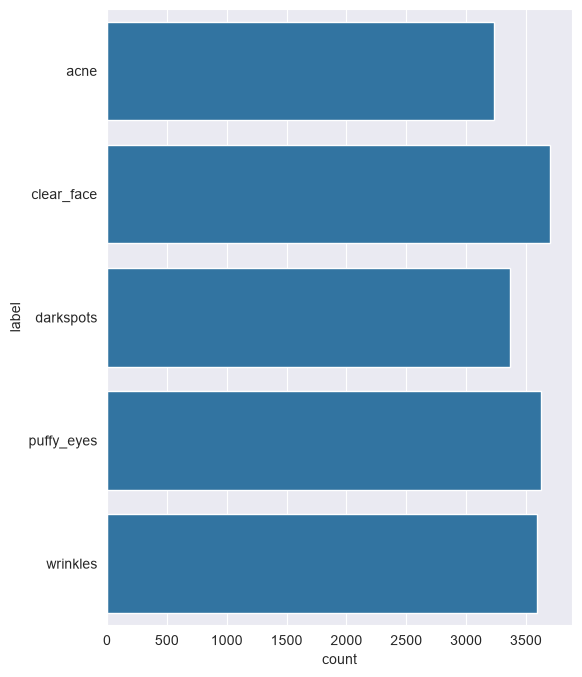

In [36]:
# Visualisasi distribusi kelas
Label = df_augmented["label"]
plt.figure(figsize=(6, 8))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [37]:
df_augmented.groupby(["label"]).size()

label
acne          3234
clear_face    3700
darkspots     3368
puffy_eyes    3622
wrinkles      3596
dtype: int64

In [49]:
df_augmented.head(-10)

,path,file_name,label
0,dataset/skin_ageing_symptoms\clear_face\augmen...,augmented_image_1443.jpg,clear_face
1,dataset/skin_ageing_symptoms\clear_face\augmen...,augmented_image_581.jpg,clear_face
2,dataset/skin_ageing_symptoms\puffy_eyes\aug_12...,aug_124_aug_2.png,puffy_eyes
3,dataset/skin_ageing_symptoms\puffy_eyes\augmen...,augmented_image_113.jpg,puffy_eyes
4,dataset/skin_ageing_symptoms\puffy_eyes\celeba...,celeba_puffy_eyes_light_02187.png,puffy_eyes
...,...,...,...
17505,dataset/skin_ageing_symptoms\clear_face\augmen...,augmented_image_1835.jpg,clear_face
17506,dataset/skin_ageing_symptoms\puffy_eyes\augmen...,augmented_image_873.jpg,puffy_eyes
17507,dataset/skin_ageing_symptoms\puffy_eyes\celeba...,celeba_puffy_eyes_dark_00298.png,puffy_eyes
17508,dataset/skin_ageing_symptoms\puffy_eyes\augmen...,augmented_image_126.jpg,puffy_eyes


In [39]:
df_augmented = df_augmented.sample(frac=1).reset_index(drop=True)

In [40]:
df_augmented.head()

,path,file_name,label
0,dataset/skin_ageing_symptoms\clear_face\augmen...,augmented_image_1443.jpg,clear_face
1,dataset/skin_ageing_symptoms\clear_face\augmen...,augmented_image_581.jpg,clear_face
2,dataset/skin_ageing_symptoms\puffy_eyes\aug_12...,aug_124_aug_2.png,puffy_eyes
3,dataset/skin_ageing_symptoms\puffy_eyes\augmen...,augmented_image_113.jpg,puffy_eyes
4,dataset/skin_ageing_symptoms\puffy_eyes\celeba...,celeba_puffy_eyes_light_02187.png,puffy_eyes


In [41]:
X = df_augmented['path']
y = df_augmented['label']

In [42]:
X

0        dataset/skin_ageing_symptoms\clear_face\augmen...
1        dataset/skin_ageing_symptoms\clear_face\augmen...
2        dataset/skin_ageing_symptoms\puffy_eyes\aug_12...
3        dataset/skin_ageing_symptoms\puffy_eyes\augmen...
4        dataset/skin_ageing_symptoms\puffy_eyes\celeba...
                               ...                        
17515    dataset/skin_ageing_symptoms\acne\augmented_im...
17516    dataset/skin_ageing_symptoms\darkspots\augment...
17517    dataset/skin_ageing_symptoms\puffy_eyes\celeba...
17518             dataset/skin_ageing_symptoms\acne\87.png
17519    dataset/skin_ageing_symptoms\clear_face\augmen...
Name: path, Length: 17520, dtype: str

In [43]:
y

0        clear_face
1        clear_face
2        puffy_eyes
3        puffy_eyes
4        puffy_eyes
            ...    
17515          acne
17516     darkspots
17517    puffy_eyes
17518          acne
17519    clear_face
Name: label, Length: 17520, dtype: str

In [44]:
train_size = int(len(df_augmented) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [52]:
df_tr = pd.DataFrame({'path': X_train, 'label': y_train, 'set': 'train'})
df_te = pd.DataFrame({'path': X_test, 'label': y_test, 'set': 'test'})
df_all = pd.concat([df_tr, df_te], ignore_index=True)

In [53]:
print(df_all.groupby(['label', 'set']).size())

label       set  
acne        test      615
            train    2619
clear_face  test      751
            train    2949
darkspots   test      681
            train    2687
puffy_eyes  test      765
            train    2857
wrinkles    test      692
            train    2904
dtype: int64


In [55]:
df_all.head(-10)

,path,label,set
0,dataset/skin_ageing_symptoms\clear_face\augmen...,clear_face,train
1,dataset/skin_ageing_symptoms\clear_face\augmen...,clear_face,train
2,dataset/skin_ageing_symptoms\puffy_eyes\aug_12...,puffy_eyes,train
3,dataset/skin_ageing_symptoms\puffy_eyes\augmen...,puffy_eyes,train
4,dataset/skin_ageing_symptoms\puffy_eyes\celeba...,puffy_eyes,train
...,...,...,...
17505,dataset/skin_ageing_symptoms\clear_face\augmen...,clear_face,test
17506,dataset/skin_ageing_symptoms\puffy_eyes\augmen...,puffy_eyes,test
17507,dataset/skin_ageing_symptoms\puffy_eyes\celeba...,puffy_eyes,test
17508,dataset/skin_ageing_symptoms\puffy_eyes\augmen...,puffy_eyes,test


In [57]:
dataset_path = './dataset-final'
# Buat direktori train dan test
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
        file_path = os.path.join(
            lung_path, row['label'], row['image'].split('.')[0]
        )

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path, row['set'], row['label'])) == False:
        os.makedirs(os.path.join(dataset_path, row['set'], row['label']))

    # Tentukan tujuan file
    destination_file_name = os.path.basename(file_path)
    file_dest = os.path.join(
        dataset_path, row['set'], row['label'], destination_file_name
    )

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path, file_dest)

17520it [00:07, 2305.09it/s]


In [ ]:
TRAIN_DIR = './dataset-final/train'
TEST_DIR = './dataset-final/test'

train_acne = os.path.join(TRAIN_DIR, 'acne')
train_clear_face = os.path.join(TRAIN_DIR, 'clear_face')
train_darkspots = os.path.join(TRAIN_DIR, "darkspots")
train_puffy_eyes = os.path.join(TRAIN_DIR, 'puffy_eyes')
train_wrinkles = os.path.join(TRAIN_DIR, 'wrinkles')

In [66]:
print("Total number of acne images in training set: ", len(os.listdir(train_acne)))
print("Total number of clear face images in training set: ",len(os.listdir(train_clear_face)))
print("Total number of darkspots images in training set: ",len(os.listdir(train_darkspots)))
print("Total number of puffy eyes images in training set: ",len(os.listdir(train_puffy_eyes)))
print("Total number of wrinkles images in training set: ",len(os.listdir(train_wrinkles)))

Total number of acne images in training set:  2402
Total number of clear face images in training set:  2562
Total number of darkspots images in training set:  2404
Total number of puffy eyes images in training set:  2052
Total number of wrinkles images in training set:  2544


In [ ]:
test_acne = os.path.join(TEST_DIR, 'acne')
test_clear_face = os.path.join(TEST_DIR, 'clear_face')
test_darkspots = os.path.join(TEST_DIR, 'darkspots')
test_puffy_eyes = os.path.join(TEST_DIR, 'puffy_eyes')
test_wrinkles = os.path.join(TEST_DIR, 'wrinkles')

In [69]:
print("Total number of acne images in testing set: ", len(os.listdir(test_acne)))
print("Total number of clear face images in testing set: ",len(os.listdir(test_clear_face)))
print("Total number of darkspots images in testing set: ",len(os.listdir(test_darkspots)))
print("Total number of puffy eyes images in testing set: ",len(os.listdir(test_puffy_eyes)))
print("Total number of wrinkles images in testing set: ",len(os.listdir(test_wrinkles)))

Total number of acne images in testing set:  603
Total number of clear face images in testing set:  731
Total number of darkspots images in testing set:  667
Total number of puffy eyes images in testing set:  714
Total number of wrinkles images in testing set:  672


In [70]:
datagen = ImageDataGenerator(rescale=1/255.0, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1/255.0)

In [71]:
datagen

In [72]:
test_datagen

In [159]:
train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=32,
    target_size=(150, 150),
    color_mode='rgb',
    class_mode='sparse',
    subset='training',
    shuffle=True,
)

validation_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=32,
    target_size=(150, 150),
    color_mode='rgb',
    class_mode='sparse',
    subset='validation',
    shuffle=False,
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    batch_size=1,
    target_size=(150, 150),
    color_mode='rgb',
    class_mode='sparse',
    shuffle=False,
)

Found 9574 images belonging to 5 classes.
Found 2390 images belonging to 5 classes.
Found 3387 images belonging to 5 classes.


In [160]:
model = Sequential();

# Layer 1
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150, 150, 3)))
model.add(BatchNormalization())
model.add(MaxPool2D(2, 2))

# Layer 2
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(2, 2))

# Layer 3
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(2, 2))

# Layer 4
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(2, 2))

# Flatten layer
model.add(Flatten())

# # 1nd Dense Layer
model.add(Dense(128, activation="relu"))

# 1nd Dropout Layer
model.add(Dropout(0.5))

# 2nd Dense Layer
model.add(Dense(64, activation="relu"))

# 2nd Dropout Layer
model.add(Dropout(0.3))

# # Final Dense layer 
model.add(Dense(5, activation="softmax"))

In [176]:
model.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [177]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,053 (6.02 MB)

 Trainable params: 1,577,349 (6.02 MB)

 Non-trainable params: 704 (2.75 KB)

In [178]:
# Hitung jumlah data tiap kelas
count_acne = len(os.listdir(train_acne))
count_clear_face = len(os.listdir(train_clear_face))
count_darkspots = len(os.listdir(train_darkspots))
count_puffy_eyes = len(os.listdir(train_puffy_eyes))
count_wrinkles = len(os.listdir(train_wrinkles))

total = (
    count_acne + count_clear_face + count_darkspots + count_puffy_eyes + count_wrinkles
)
n_classes = 5

weight_0 = (1 / count_acne) * (total) / n_classes
weight_1 = (1 / count_clear_face) * (total) / n_classes
weight_2 = (1 / count_darkspots) * (total) / n_classes
weight_3 = (1 / count_puffy_eyes) * (total) / n_classes
weight_4 = (1 / count_wrinkles) * (total) / n_classes

class_weights = {
    0: weight_0,  # acne
    1: weight_1,  # clear_face
    2: weight_2,  # darkspots
    3: weight_3,  # puff_eyes
    4: weight_4,  # wrinkles
}

print(class_weights)

{0: 0.9961698584512906, 1: 0.9339578454332553, 2: 0.9953410981697172, 3: 1.1660818713450292, 4: 0.940566037735849}


In [170]:
early_stop = EarlyStopping(
    monitor="val_loss",  # bisa juga 'val_accuracy'
    patience=10,  # berhenti kalau 10 epoch berturut-turut tidak membaik
    restore_best_weights=True,  # otomatis kembalikan bobot terbaik, bukan bobot terakhir
    verbose=1,
)

In [171]:
checkpoint = ModelCheckpoint(
    filepath="model_cnn_facial_skin_ageing.keras",  # atau .h5
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)

In [172]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
)

In [179]:
history = model.fit(
    train_generator,
    epochs=60,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, reduce_lr],
)

Epoch 1/60
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9091 - loss: 0.3038
Epoch 1: val_accuracy did not improve from 0.85900
300/300 ━━━━━━━━━━━━━━━━━━━━ 661s 2s/step - accuracy: 0.9091 - loss: 0.3038 - val_accuracy: 0.8063 - val_loss: 1.6571 - learning_rate: 0.0010
Epoch 2/60
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9081 - loss: 0.3020
Epoch 2: val_accuracy did not improve from 0.85900
300/300 ━━━━━━━━━━━━━━━━━━━━ 696s 2s/step - accuracy: 0.9081 - loss: 0.3020 - val_accuracy: 0.8397 - val_loss: 0.9301 - learning_rate: 0.0010
Epoch 3/60
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9074 - loss: 0.2998
Epoch 3: val_accuracy did not improve from 0.85900
300/300 ━━━━━━━━━━━━━━━━━━━━ 509s 2s/step - accuracy: 0.9074 - loss: 0.2998 - val_accuracy: 0.7741 - val_loss: 0.8864 - learning_rate: 0.0010
Epoch 4/60
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.9340 - loss: 0.2147
Epoch 4: val_accuracy did not improve from 0.85900
300/300 ━━━━━━━━━━━━━━━━━━━

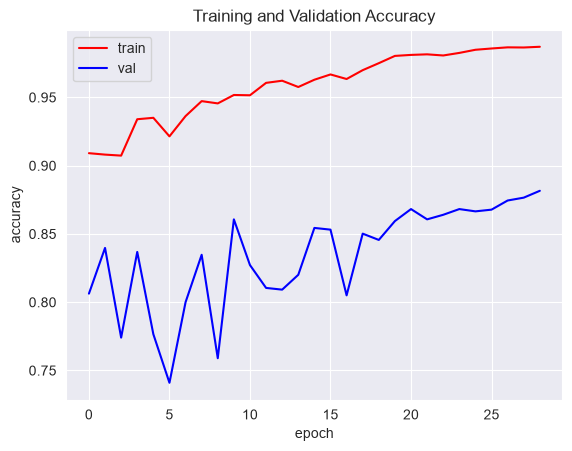

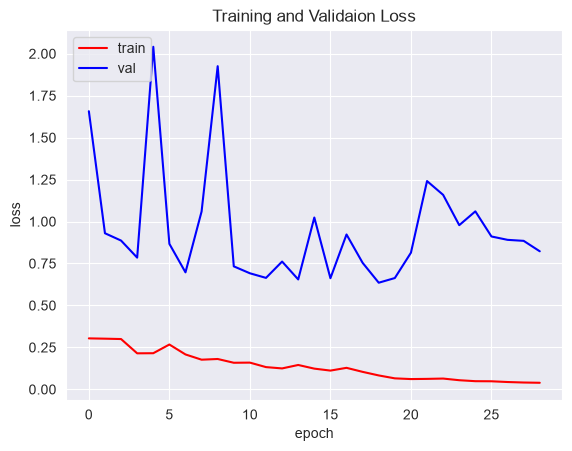

In [180]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(len(acc))

plt.plot(epochs, acc, "r")
plt.plot(epochs, val_acc, "b")
plt.title("Training and Validation Accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

plt.plot(epochs, loss, "r")
plt.plot(epochs, val_loss, "b")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.title("Training and Validaion Loss")
plt.show()

In [181]:
# Reset generator
train_generator.reset()
test_generator.reset()

# Evaluasi Training Set
train_loss, train_acc = model.evaluate(train_generator, verbose=0)

# Evaluasi Testing Set
test_loss, test_acc = model.evaluate(test_generator, verbose=0)

# Tampilkan hasil
print(f"Training Accuracy : {train_acc * 100:.2f}%")
print(f"Testing Accuracy  : {test_acc * 100:.2f}%")

print(f"Training Loss     : {train_loss:.4f}")
print(f"Testing Loss      : {test_loss:.4f}")

Training Accuracy : 98.58%
Testing Accuracy  : 90.61%
Training Loss     : 0.0526
Testing Loss      : 0.3695


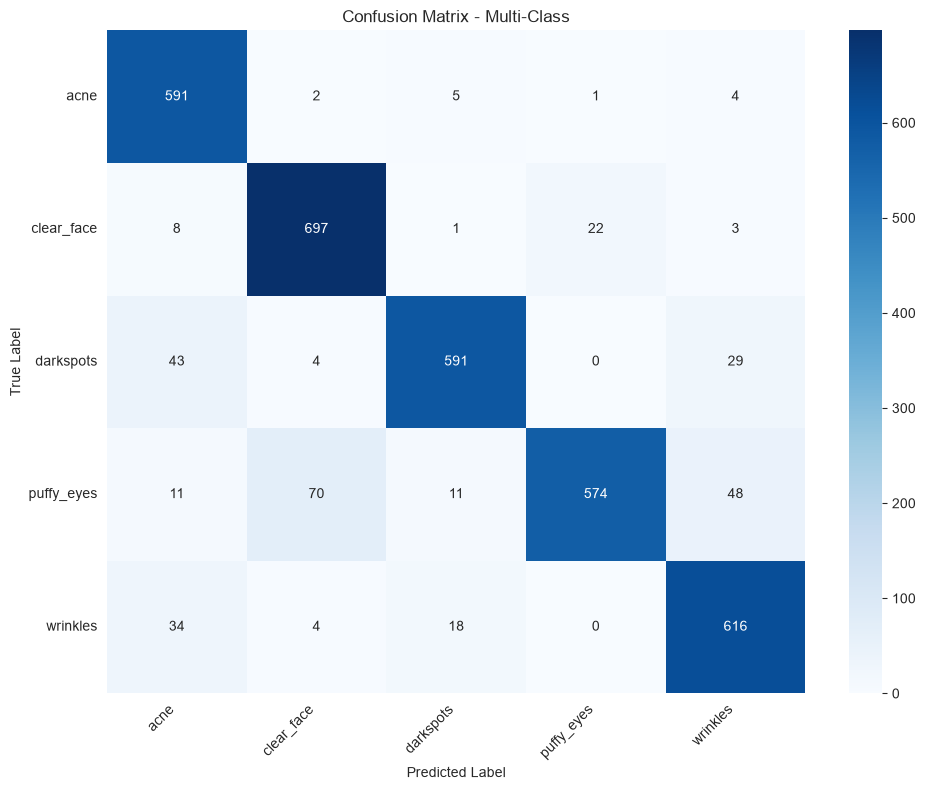

Classification Report:
              precision    recall  f1-score   support

        acne     0.8603    0.9801    0.9163       603
  clear_face     0.8970    0.9535    0.9244       731
   darkspots     0.9441    0.8861    0.9142       667
  puffy_eyes     0.9615    0.8039    0.8757       714
    wrinkles     0.8800    0.9167    0.8980       672

    accuracy                         0.9061      3387
   macro avg     0.9086    0.9080    0.9057      3387
weighted avg     0.9100    0.9061    0.9054      3387



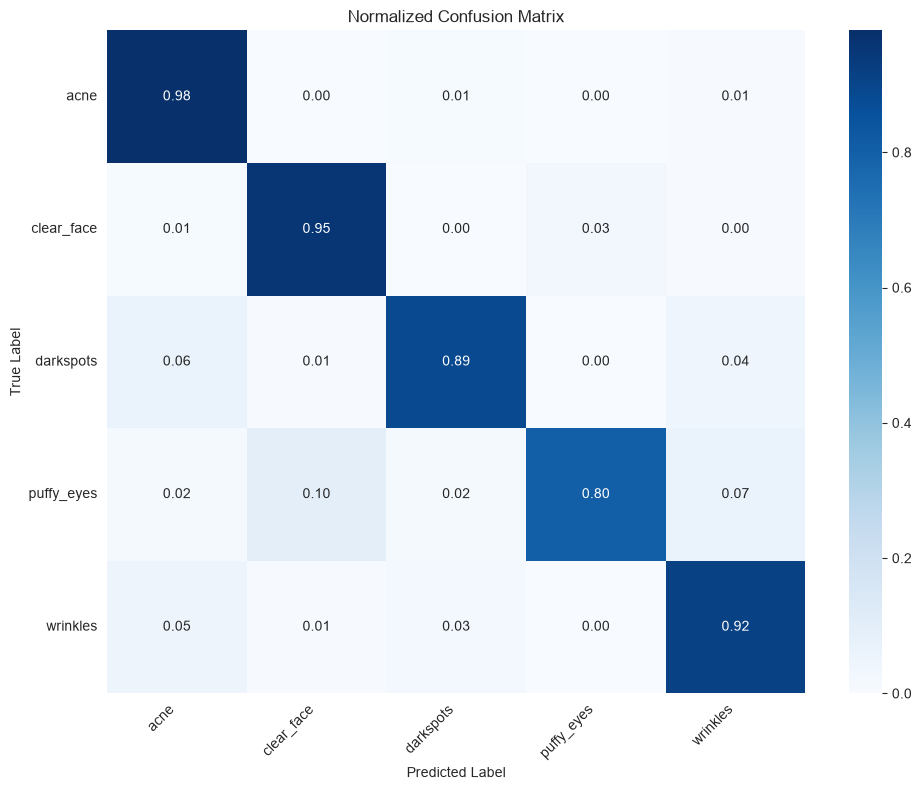


Akurasi per kelas:
acne: 98.01%
clear_face: 95.35%
darkspots: 88.61%
puffy_eyes: 80.39%
wrinkles: 91.67%


In [185]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Reset generator agar urutan data sesuai label
test_generator.reset()

# Prediksi probabilitas untuk seluruh data test
y_pred_prob = model.predict(test_generator, verbose=0)

# Ambil kelas dengan probabilitas tertinggi (multi-class)
y_pred = np.argmax(y_pred_prob, axis=1)

# Label sebenarnya
y_true = test_generator.classes

# Nama-nama kelas (urut sesuai index)
class_labels = list(test_generator.class_indices.keys())

# Hitung confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar=True,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Multi-Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report (precision, recall, f1-score per kelas)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# (Opsional) Normalized confusion matrix — berguna kalau jumlah data per kelas tidak seimbang
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# (Opsional) Akurasi per kelas dari confusion matrix
print("\nAkurasi per kelas:")
for i, label in enumerate(class_labels):
    class_acc = cm[i, i] / cm[i].sum()
    print(f"{label}: {class_acc*100:.2f}%")

In [214]:
import json

# Mencetak class indicate dari train generator
with open("./saved_model/class_indices.json", "w") as f:
    json.dump(class_indices, f, indent=4)

**Inferensi (Demo)**

In [213]:
model = load_model("./saved_model/model_cnn_facial_skin_ageing.h5")

In [224]:
with open("saved_model/class_indices.json", "r") as f:
    class_indices = json.load(f)

idx_to_class = {v: k for k, v in class_indices.items()}

IMG_SIZE = (150, 150)  # sesuaikan dengan input size pada model yang sudah dibangun.

In [225]:
from tkinter import Tk, filedialog

def select_image():
    root = Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    img_path = filedialog.askopenfilename(
        title="Pilih gambar untuk prediksi",
        filetypes=[("Image files", "*.jpg *.jpeg *.png")],
    )
    root.destroy()
    return img_path

In [226]:
def preprocess_image(img_path, target_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img_array, img

In [227]:
def predict_new_image(img_path):
    img_array, original_img = preprocess_image(img_path)

    predictions = model.predict(img_array, verbose=0)[0]
    predicted_idx = np.argmax(predictions)
    predicted_label = idx_to_class[predicted_idx]
    confidence = predictions[predicted_idx] * 100

    print("=" * 40)
    print(f"Gambar        : {img_path}")
    print(f"Prediksi      : {predicted_label}")
    print(f"Confidence    : {confidence:.2f}%")
    print("=" * 40)

    print("\nPersentase confidence per kelas:")
    sorted_indices = np.argsort(predictions)[::-1]
    for idx in sorted_indices:
        print(f"  {idx_to_class[idx]:<20}: {predictions[idx]*100:.2f}%")

    plt.figure(figsize=(5, 5))
    plt.imshow(original_img)
    plt.title(f"Prediksi: {predicted_label} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

    return predicted_label, confidence, predictions

Gambar        : D:/Machine Learning/Belajar_Fundamental_Deep_Learning/Face_Skin_Ageing_Image_Classification/nenek_insidius.jpg
Prediksi      : wrinkles
Confidence    : 74.90%

Persentase confidence per kelas:
  wrinkles            : 74.90%
  acne                : 18.48%
  darkspots           : 4.55%
  puffy_eyes          : 1.95%
  clear_face          : 0.13%


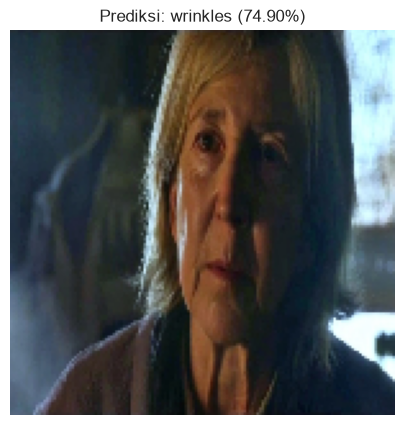

In [228]:
img_path = select_image()

if img_path:
    label, conf, all_scores = predict_new_image(img_path)
else:
    print("Tidak ada gambar yang dipilih.")

In [196]:
import json
import os

# Buat folder untuk menyimpan model (opsional, biar rapi)
save_dir = "saved_model"
os.makedirs(save_dir, exist_ok=True)
model.save(f"{save_dir}/model_cnn_facial_skin_ageing.h5")
print(f"Model berhasil disimpan sebagai {save_dir}/model.h5")
# ============================================
try:
    with open(f"{save_dir}/training_history.json", "w") as f:
        json.dump(history.history, f, indent=4)
    print(f"Training history berhasil disimpan di {save_dir}/training_history.json")
except NameError:
    print("Variabel 'history' tidak ditemukan, history training tidak disimpan.")

Model berhasil disimpan sebagai saved_model/model.h5
Training history berhasil disimpan di saved_model/training_history.json


In [197]:
# Menyimpan model dalam format SavedModel
tf.saved_model.save(model, save_dir)

INFO:tensorflow:Assets written to: saved_model\assets


INFO:tensorflow:Assets written to: saved_model\assets


**Menyimpan Model dalam tflite**

In [200]:
# Convert SavedModel menjadi model_cnn_facial_skin_ageing.tflite
save_dir_tflite = './tflite'
converter = tf.lite.TFLiteConverter.from_saved_model(save_dir)
tflite_model = converter.convert()

In [201]:
tflite_model_file = pathlib.Path(os.path.join(save_dir_tflite, 'model_cnn_facial_skin_ageing.tflite'))
tflite_model_file.write_bytes(tflite_model)

22608

**Membuat label.txt (class yang ada)**

In [203]:
class_indices = train_generator.class_indices
labels = sorted(class_indices.items(), key=lambda x: x[1])

with open(os.path.join(save_dir_tflite, 'label.txt'), 'w') as f:
    for class_name, idx in labels:
        f.write(f'{class_name}\n')

print('label.txt berhasil dibuat')
print('Isi label.txt:')
for class_name, idx in labels:
    print(f'{idx}: {class_name}')

label.txt berhasil dibuat
Isi label.txt:
0: acne
1: clear_face
2: darkspots
3: puffy_eyes
4: wrinkles


**Menyimpan Model dengan TensorFlow JS**

In [207]:
!tensorflowjs_converter --input_format=keras model.h5 tfjs_model

I0000 00:00:1788677154.994257   22888 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788677156.147244   22888 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
D:\Machine Learning\Belajar_Fundamental_Deep_Learning\.venv\Lib\site-packages\tensorflowjs\read_weights.py:28: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  np.uint8, np.uint16, np.object, np.bool]
Traceback (most recent call last):
  File "<frozen runpy>", line 203, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\Machine Learning\Belajar_Fundamental_Deep